In [1]:
# Installation des bibliothèques nécessaires
!pip install pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.decomposition import NMF

# Chargement du dataset directement via URL (Dataset Red Wine Quality)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


/tmp/ipython-input-779741984.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


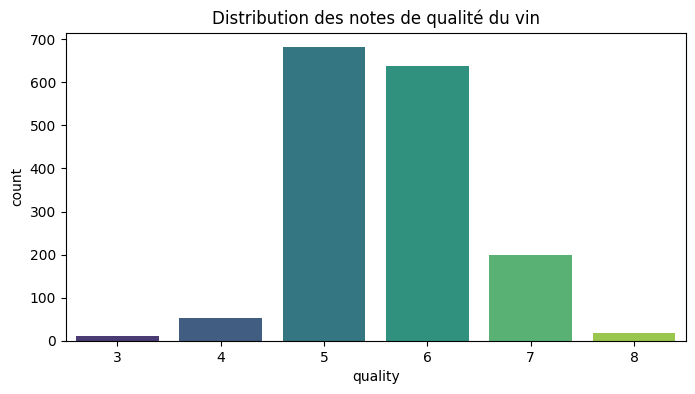

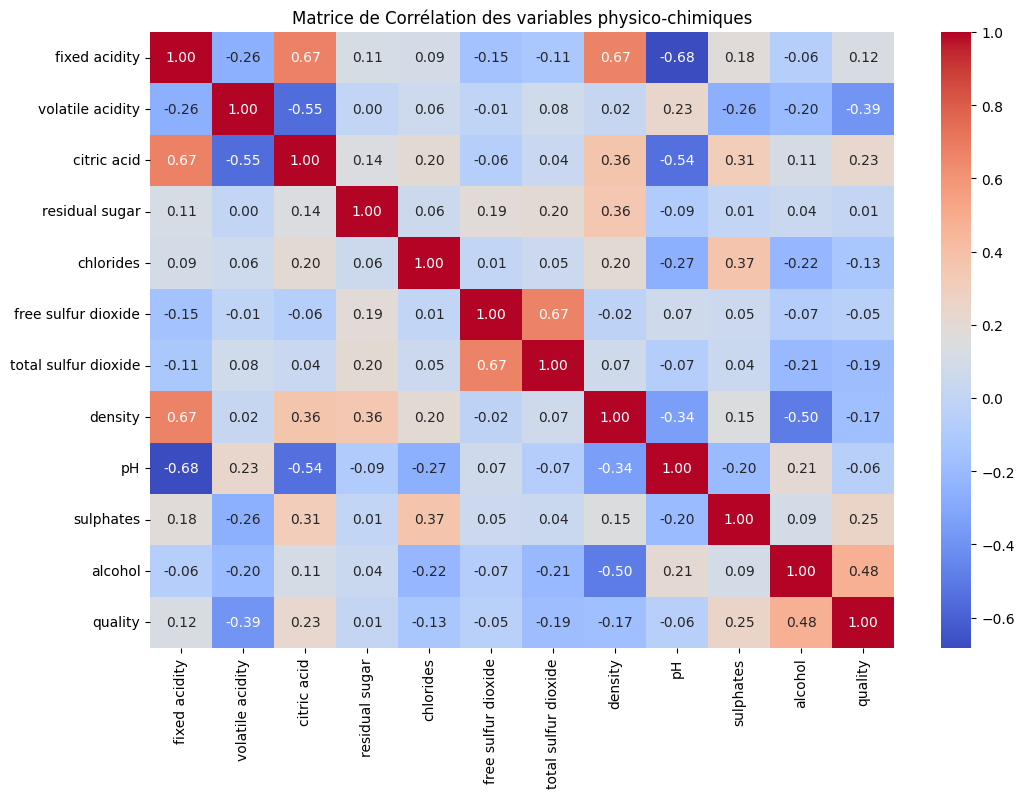

In [2]:
# Vérification des valeurs manquantes
print(df.isnull().sum())

# Visualisation de la distribution de la variable cible 'quality'
plt.figure(figsize=(8, 4))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Distribution des notes de qualité du vin')
plt.show()

# Matrice de corrélation pour identifier les variables clés
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation des variables physico-chimiques')
plt.show()

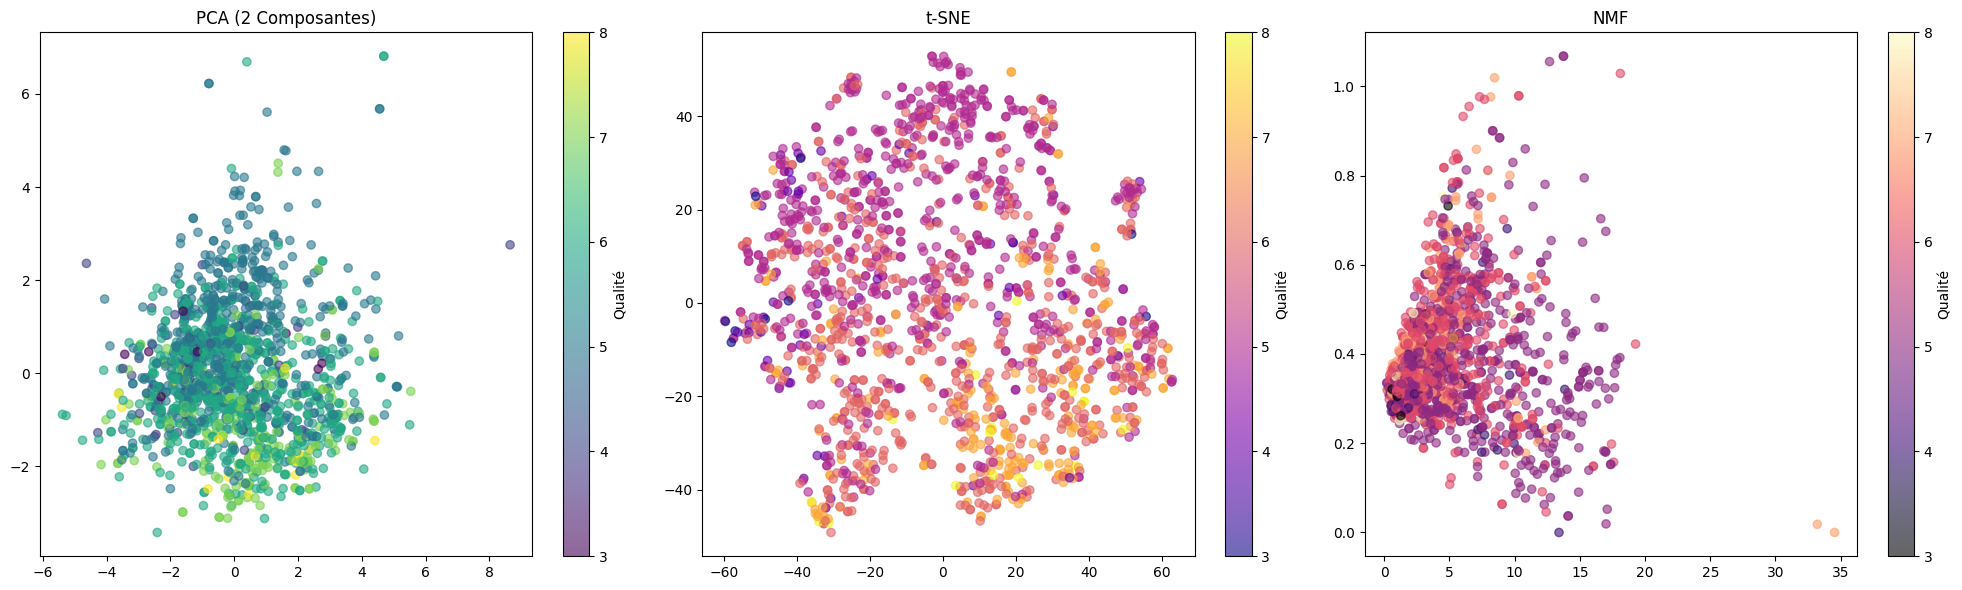

In [3]:
# Séparation des features (X) et de la cible (y)
X = df.drop('quality', axis=1)
y = df['quality']

# Standardisation (Crucial pour PCA et t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 1. PCA (Analyse en Composantes Principales) ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- 2. t-SNE ---
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# --- 3. NMF (Non-negative Matrix Factorization) ---
# Note : NMF nécessite des valeurs positives, on utilise donc X et non X_scaled
nmf = NMF(n_components=2, init='random', random_state=42, max_iter=1000)
X_nmf = nmf.fit_transform(X)

# Visualisation comparative
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# Plot PCA
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
ax1.set_title('PCA (2 Composantes)')
fig.colorbar(scatter1, ax=ax1, label='Qualité')

# Plot t-SNE
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='plasma', alpha=0.6)
ax2.set_title('t-SNE')
fig.colorbar(scatter2, ax=ax2, label='Qualité')

# Plot NMF
scatter3 = ax3.scatter(X_nmf[:, 0], X_nmf[:, 1], c=y, cmap='magma', alpha=0.6)
ax3.set_title('NMF')
fig.colorbar(scatter3, ax=ax3, label='Qualité')

plt.tight_layout()
plt.show()

In [4]:
!pip install mlflow pyngrok --quiet

import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Initialisation d'une expérience MLflow
mlflow.set_experiment("Wine_Quality_Clustering")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00


2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/15 21:08:48 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/15 21:08:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/15 21:08:48 INFO mlflow.store.db.utils: Updating database tables
2026/02/15 21:08:48 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/15 21:08:48 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/15 21:08:49 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/02/15 21:0

<Experiment: artifact_location='/content/mlruns/1', creation_time=1771189731121, experiment_id='1', last_update_time=1771189731121, lifecycle_stage='active', name='Wine_Quality_Clustering', tags={}>

In [5]:
def run_kmeans(n_clusters):
    with mlflow.start_run(run_name=f"KMeans_k_{n_clusters}"):
        model = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = model.fit_predict(X_scaled)

        # Calcul de la métrique Silhouette
        score = silhouette_score(X_scaled, labels)

        # Logging MLflow
        mlflow.log_param("n_clusters", n_clusters)
        mlflow.log_metric("silhouette_score", score)

        print(f"K-Means k={n_clusters} | Silhouette: {score:.4f}")
        return labels

# Test de k=2 à k=5
for k in range(2, 6):
    run_kmeans(k)

K-Means k=2 | Silhouette: 0.2137
K-Means k=3 | Silhouette: 0.1892
K-Means k=4 | Silhouette: 0.1716
K-Means k=5 | Silhouette: 0.1901


In [6]:
# 1. DBSCAN
with mlflow.start_run(run_name="DBSCAN_Default"):
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    db_labels = dbscan.fit_predict(X_scaled)
    # On logue les paramètres
    mlflow.log_param("eps", 0.5)
    mlflow.log_param("min_samples", 5)

# 2. Agglomerative Clustering (Dendrogramme)
with mlflow.start_run(run_name="Agglomerative_3_Clusters"):
    agglo = AgglomerativeClustering(n_clusters=3)
    agglo_labels = agglo.fit_predict(X_scaled)
    mlflow.log_param("n_clusters", 3)

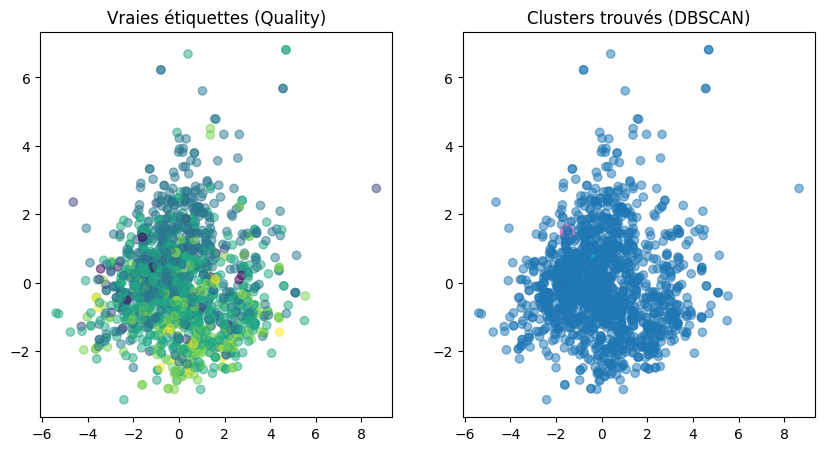

In [7]:
# Visualisation sur les axes de la PCA (Phase 1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title("Vraies étiquettes (Quality)")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', alpha=0.5)
plt.title("Clusters trouvés (DBSCAN)")

plt.show()

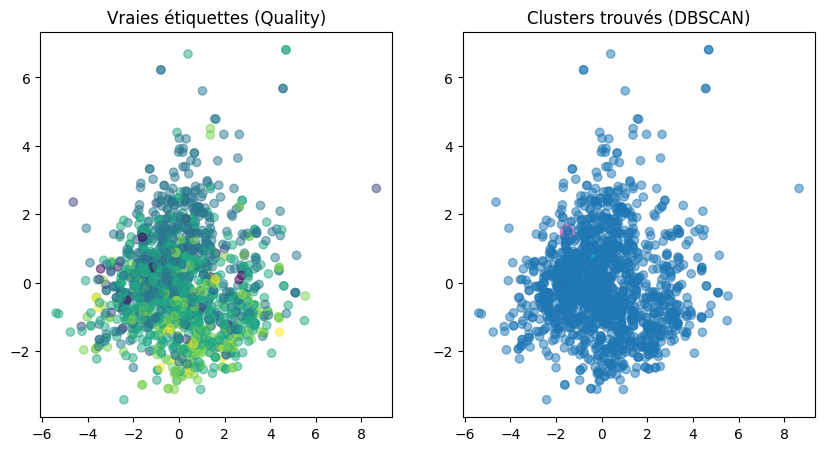

In [8]:
# Visualisation sur les axes de la PCA (Phase 1)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5)
plt.title("Vraies étiquettes (Quality)")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_labels, cmap='tab10', alpha=0.5)
plt.title("Clusters trouvés (DBSCAN)")

plt.show()

In [9]:
# Transformation de la cible en 3 classes : Mauvais (3-4), Moyen (5-6), Bon (7-8)
bins = (2, 4, 6, 8)
group_names = ['Mauvais', 'Moyen', 'Bon']
df['quality_label'] = pd.cut(df['quality'], bins=bins, labels=group_names)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encodage des labels
le = LabelEncoder()
y_class = le.fit_transform(df['quality_label'])

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

In [10]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Test du SVM
with mlflow.start_run(run_name="SVM_Classifier"):
    svm_model = SVC(kernel='rbf', C=1.0)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    mlflow.log_param("kernel", "rbf")
    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(svm_model, "svm_model")
    print(f"SVM Accuracy: {acc:.4f}")

# 2. Test du Random Forest (Méthode d'Ensemble)
with mlflow.start_run(run_name="RandomForest_Champion"):
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    acc_rf = accuracy_score(y_test, y_pred_rf)
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_metric("accuracy", acc_rf)
    mlflow.sklearn.log_model(rf_model, "rf_model")
    print(f"Random Forest Accuracy: {acc_rf:.4f}")

2026/02/15 21:12:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/lib/python3.12/dist-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


SVM Accuracy: 0.8406


2026/02/15 21:12:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/usr/local/lib/python3.12/dist-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Random Forest Accuracy: 0.8750
